# Mini-3 



**Name:** *Ashutosh Kumar*  
**Course:** EECS 590 Reinforcement Learning

## Problem 1: Cadmium Rod Control in a Nuclear Reactor
**Mini 3 — Problem 1 Solution**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
from typing import Tuple, List, Optional, Dict
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Imports OK')

Imports OK


---
## Question 1: MDP Formulation

### The Underlying Process

The true reactivity $\mu_t \in \mathbb{R}$ is a **hidden** (latent) variable. The agent observes only a noisy gauge reading $z_t \sim \mathcal{N}(\mu_t, \sigma^2)$. Since the agent cannot observe $\mu_t$, this is technically a **POMDP** (Partially Observable Markov Decision Process) [Kaelbling et al., 1998]. However, following the assignment instructions, we approximate it as an MDP by treating the discretized observation $z_t$ as the state — an approach common in practical RL applications [Sutton & Barto, 2018, Ch. 17.3].

### State Space $\mathcal{S}$

We partition the observation range $[\mu_{\min}, \mu_{\max}]$ into $n$ equal-width bins and define $\mathcal{S} = \{0, 1, \ldots, n-1\}$, plus a terminal **meltdown** state. Given bin width $\Delta = (\mu_{\max} - \mu_{\min})/n$, observation $z_t$ maps to state:

$$s_t = \text{clip}\left(\left\lfloor \frac{z_t - \mu_{\min}}{\Delta} \right\rfloor,\; 0,\; n-1\right)$$

### Action Space $\mathcal{A}$

$$\mathcal{A} = \{-k, -k+1, \ldots, -1, 0, +1, \ldots, k\}$$

with $k = 2$, giving $|\mathcal{A}| = 5$ actions. Positive $a_t$ **inserts** rods (suppresses reactivity), negative $a_t$ **withdraws** rods (increases reactivity).

### Transition Dynamics

The effective transition $P(s' \mid s, a)$ is composed of two stages:

1. **Mean evolution:** $\mu_{t+1} = \text{clip}(\mu_t - \alpha , a_t + d(\mu_t) + \varepsilon_t,\; \mu_{\min},\; \mu_{\max})$, where $d(\mu) = \delta \cdot \mathbb{1}[\mu \geq \mu_{\text{hot}}]$ and $\varepsilon_t \sim \mathcal{N}(0, \sigma_T^2)$.

2. **Observation:** $z_{t+1} \sim \mathcal{N}(\mu_{t+1}, \sigma^2)$, then discretized to $s_{t+1}$.

Because $\mu_t$ is hidden, the tuple $(z_t, a_t)$ does **not** form a true Markov chain — the next observation depends on $\mu_t$, not $z_t$. However, since $z_t$ is an unbiased (noisy) estimate of $\mu_t$, acting as if $s_t$ were the state is the best the agent can do without a belief tracker.

### Reward Function

The agent receives $R_{t+1} \sim \mathcal{N}(\bar{R}(\mu_t, a_t),\; \sigma_R^2)$ where:

$$\bar{R}(\mu, a) = \begin{cases} w(\mu) - c|a| & \text{if } \mu_{\text{lo}} \leq \mu \leq \mu_{\text{hi}}, \\ -c|a| & \text{if } \mu < \mu_{\text{lo}}, \\ -M & \text{if } \mu \geq \mu_{\max}. \end{cases}$$

with $w(\mu) = \mu - \mu_{\text{lo}}$ (power output) and $c \geq 0$ a small rod-movement cost.

### Discount Factor $\gamma$

We use $\gamma = 0.95$. This is moderately high because:
- The agent must plan ahead to avoid meltdown (too low $\gamma$ would make it myopic and ignore the approaching critical region).
- But not $\gamma = 1.0$, because episodes can be long and the task is continuing in nature — mild discounting ensures value estimates converge.

### Termination

An episode terminates either:
- **Meltdown:** $\mu_t \geq \mu_{\max}$ (early termination, large penalty $-M$).
- **Safe shutdown:** $t \geq T$ (horizon reached, successful operation).

### Consequences for Value Functions

Because the state $s_t$ is a noisy proxy for $\mu_t$:
- The value function $V^\pi(s)$ and $Q^\pi(s, a)$ learned by tabular methods are **expected values under the aliasing** induced by binning. Two different $\mu$ values in the same bin get the same $Q$.
- Finer binning ($n$ large) reduces aliasing but increases the state space and slows learning.
- The non-Markovian nature means the true optimal policy depends on the full history, but our tabular methods will converge to the best Markov (memoryless) policy for the discretized states.

---
## Environment Implementation

In [2]:
@dataclass
class ReactorConfig:
    """All configurable parameters for the reactor environment."""
    mu_min: float = 0.0
    mu_max: float = 10.0
    mu_lo: float = 3.0       # lower bound of productive range
    mu_hi: float = 7.0       # upper bound of productive range
    mu_hot: float = 5.0      # drift threshold
    alpha: float = 1.0       # rod effectiveness
    delta: float = 0.3       # intrinsic drift rate when hot
    sigma_obs: float = 0.5   # observation noise std
    sigma_proc: float = 0.3  # process noise std
    sigma_rew: float = 0.5   # reward noise std
    k: int = 2               # max rod increments
    c: float = 0.1           # rod movement cost
    M: float = 50.0          # meltdown penalty
    n_bins: int = 20         # number of discretization bins
    T: int = 200             # episode horizon
    gamma: float = 0.95      # discount factor


class ReactorEnv:
    """
    Nuclear Reactor Cadmium Rod Control Environment.
    
    Implements the stochastic process described in Mini-3 Problem 1:
    - Hidden mean reactivity mu_t evolves under agent control + drift + noise
    - Agent observes noisy gauge z_t ~ N(mu_t, sigma_obs^2)
    - State is discretized z_t into one of n_bins bins
    - Reward is noisy power output in productive range, penalty for meltdown
    """

    def __init__(self, cfg: ReactorConfig = ReactorConfig(), seed: int = 42):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)

        # Derived quantities
        self.actions = list(range(-cfg.k, cfg.k + 1))  # [-2,-1,0,1,2]
        self.n_actions = len(self.actions)
        self.n_states = cfg.n_bins  # bins 0..n_bins-1
        self.bin_width = (cfg.mu_max - cfg.mu_min) / cfg.n_bins

        # Internal state
        self.mu = cfg.mu_min  # true mean reactivity (hidden)
        self.t = 0
        self.done = False

    def _discretize(self, z: float) -> int:
        """Map a continuous observation to a bin index."""
        idx = int((z - self.cfg.mu_min) / self.bin_width)
        return max(0, min(self.n_states - 1, idx))

    def _bin_center(self, s: int) -> float:
        """Return the center value of bin s."""
        return self.cfg.mu_min + (s + 0.5) * self.bin_width

    def reset(self) -> Tuple[int, dict]:
        """Reset to cold start: mu near mu_min."""
        self.mu = self.cfg.mu_min + self.rng.uniform(0, 0.5)
        self.t = 0
        self.done = False
        z = self.mu + self.rng.normal(0, self.cfg.sigma_obs)
        return self._discretize(z), {}

    def step(self, action_idx: int) -> Tuple[int, float, bool, bool, dict]:
        """
        Take one step.
        
        Args:
            action_idx: Index into self.actions (0..n_actions-1)
        Returns:
            next_state, reward, terminated, truncated, info
        """
        cfg = self.cfg
        a = self.actions[action_idx]  # actual rod increment

        # --- Compute reward (based on current mu, before transition) ---
        if self.mu >= cfg.mu_max:
            mean_reward = -cfg.M
        elif cfg.mu_lo <= self.mu <= cfg.mu_hi:
            mean_reward = (self.mu - cfg.mu_lo) - cfg.c * abs(a)
        else:
            mean_reward = -cfg.c * abs(a)
        reward = mean_reward + self.rng.normal(0, cfg.sigma_rew)

        # --- Mean reactivity evolves ---
        drift = cfg.delta if self.mu >= cfg.mu_hot else 0.0
        proc_noise = self.rng.normal(0, cfg.sigma_proc)
        self.mu = np.clip(
            self.mu - cfg.alpha * a + drift + proc_noise,
            cfg.mu_min, cfg.mu_max
        )
        self.t += 1

        # --- Check termination ---
        terminated = self.mu >= cfg.mu_max
        truncated = self.t >= cfg.T
        self.done = terminated or truncated

        if terminated:
            reward = -cfg.M + self.rng.normal(0, cfg.sigma_rew)

        # --- Observation ---
        z = self.mu + self.rng.normal(0, cfg.sigma_obs)
        next_state = self._discretize(z)

        info = {'mu': self.mu, 'z': z, 't': self.t, 'action': a}
        return next_state, reward, terminated, truncated, info


# Quick sanity check
env = ReactorEnv()
s, _ = env.reset()
print(f'Environment: {env.n_states} states, {env.n_actions} actions')
print(f'Actions: {env.actions}')
print(f'Bin width: {env.bin_width:.2f}')
print(f'Initial state: bin {s} (center={env._bin_center(s):.2f})')
print(f'Config: mu_range=[{env.cfg.mu_min}, {env.cfg.mu_max}], '
      f'productive=[{env.cfg.mu_lo}, {env.cfg.mu_hi}], '
      f'drift_threshold={env.cfg.mu_hot}')

Environment: 20 states, 5 actions
Actions: [-2, -1, 0, 1, 2]
Bin width: 0.50
Initial state: bin 0 (center=0.25)
Config: mu_range=[0.0, 10.0], productive=[3.0, 7.0], drift_threshold=5.0


### Verify Environment Dynamics

Let's run a few episodes with a simple policy to make sure the environment behaves as expected.

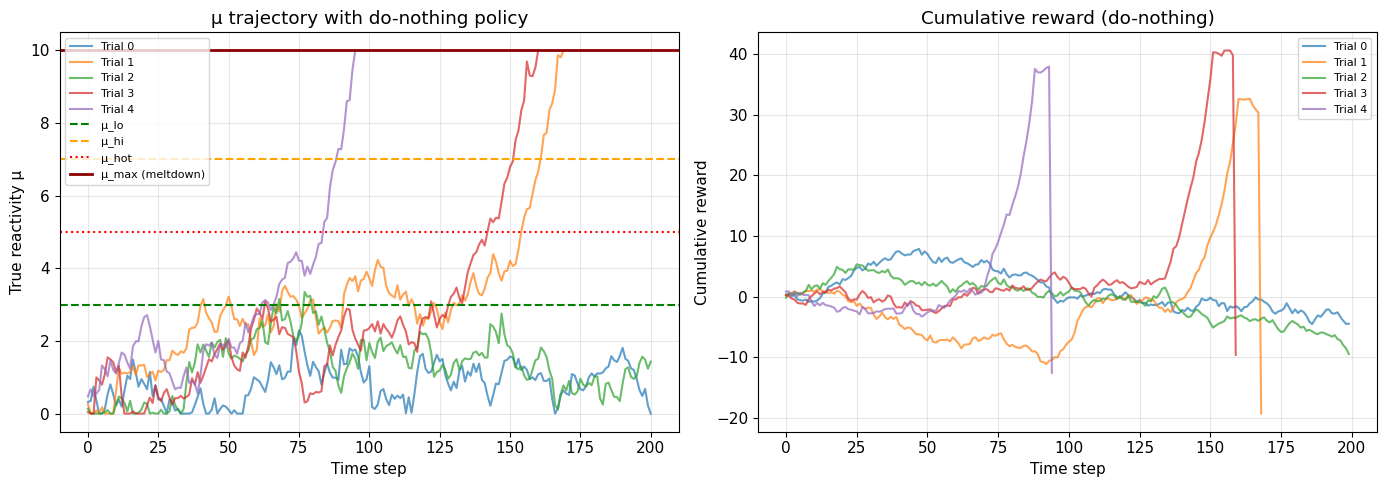

In [3]:
def run_episode(env, policy_fn, render=False):
    """Run one episode, return trajectory data."""
    s, _ = env.reset()
    states, actions_taken, rewards, mus = [s], [], [], [env.mu]
    done = False
    while not done:
        a_idx = policy_fn(s)
        s, r, term, trunc, info = env.step(a_idx)
        states.append(s)
        actions_taken.append(info['action'])
        rewards.append(r)
        mus.append(info['mu'])
        done = term or trunc
    return states, actions_taken, rewards, mus

# Policy: do nothing (action_idx=2 => a=0)
do_nothing = lambda s: 2  # action index for a=0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for trial in range(5):
    env_test = ReactorEnv(seed=trial)
    states, acts, rews, mus = run_episode(env_test, do_nothing)
    axes[0].plot(mus, alpha=0.7, label=f'Trial {trial}')
    axes[1].plot(np.cumsum(rews), alpha=0.7, label=f'Trial {trial}')

axes[0].axhline(env.cfg.mu_lo, color='green', ls='--', label='μ_lo')
axes[0].axhline(env.cfg.mu_hi, color='orange', ls='--', label='μ_hi')
axes[0].axhline(env.cfg.mu_hot, color='red', ls=':', label='μ_hot')
axes[0].axhline(env.cfg.mu_max, color='darkred', ls='-', lw=2, label='μ_max (meltdown)')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('True reactivity μ')
axes[0].set_title('μ trajectory with do-nothing policy')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Cumulative reward')
axes[1].set_title('Cumulative reward (do-nothing)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

With the do-nothing policy, the drift causes $\mu$ to climb once it crosses $\mu_{\text{hot}}$, eventually triggering meltdown. This confirms the agent **must** actively manage the rods.

---
## Question 2: Algorithm Choice and Justification

We choose **SARSA($\lambda$)** [Rummery & Niranjan, 1994; Sutton & Barto, 2018, Ch. 12] and **Q-learning** [Watkins & Dayan, 1992] as our two algorithms.

### (a) On-policy vs Off-policy

- **SARSA($\lambda$)** is **on-policy**: it evaluates and improves the policy it is actually following ($\varepsilon$-greedy). This means it learns a policy that accounts for its own exploration — in a safety-critical setting like a reactor, an on-policy algorithm naturally learns to be cautious because it "feels" the consequences of exploratory actions. The eligibility trace mechanism ($\lambda$) [Singh & Sutton, 1996] allows multi-step credit assignment within a single episode.

- **Q-learning** is **off-policy** [Watkins & Dayan, 1992]: it learns $Q^*$ (the optimal Q-function) regardless of the exploration policy. It assumes future actions will be greedy, which can be more sample-efficient but may underestimate danger during exploration — the agent might learn that being near $\mu_{\max}$ is fine (because the optimal policy would insert rods) without accounting for the fact that exploration might push it over.

**Does the choice matter?** Yes, significantly. In a safety-critical domain, SARSA's conservatism is an advantage during learning: it avoids high-reactivity states even during exploration because it accounts for the probability of taking exploratory (possibly dangerous) actions. Q-learning may achieve higher asymptotic return but suffer more meltdowns during training.

### (b) Non-Markovian Effects

The discretized observation $s_t$ is **not** Markov: the true next state depends on $\mu_t$, not $z_t$. Two episodes visiting the same bin $s$ can have very different $\mu$ values, leading to different transitions. Theoretical convergence guarantees for tabular TD methods assume the Markov property.

**Empirical expectation:** Despite violating the Markov assumption, we expect the algorithms to converge to useful policies because:
1. The observation is an unbiased estimate of $\mu_t$, so on average, acting on $z_t$ is reasonable.
2. Finer binning reduces the degree of non-Markovianness.
3. The stochasticity in the environment already forces the agent to be robust.

The learned value function will be an **average** over the hidden $\mu$ values within each bin — a form of state aliasing.

### (c) Bias-Variance Tradeoff ($\lambda$)

- **Small $\lambda$ (e.g., 0):** High bias, low variance. Updates bootstrap heavily from the current value estimate. Good when the value function is reasonably accurate, but the warm-up structure (where early states have very different dynamics from operating states) means bootstrapping from poorly-estimated early values can be misleading.

- **Large $\lambda$ (e.g., 0.8):** Lower bias, higher variance. Incorporates more actual returns, which helps during the warm-up phase where the trajectory structure is important. The warm-up → operate → possible meltdown sequence is best captured by longer traces.

**Recommendation:** A moderate-to-high $\lambda \approx 0.8$ is more appropriate because the warm-up structure creates **long temporal dependencies** between early rod-management decisions and later outcomes. Longer episodes benefit from higher $\lambda$ to propagate the meltdown penalty backward through the warm-up phase.

### (d) Choice of $\gamma$

We use $\gamma = 0.95$.

- **Not too low** ($\gamma < 0.9$): A myopic agent would focus on immediate power output and ignore the approaching meltdown threshold. The penalty $-M$ at meltdown must propagate backward through many steps to teach the agent to insert rods preemptively.

- **Not $\gamma = 1$**: The episode can last up to $T=200$ steps. With $\gamma=1$, the variance of return estimates grows with episode length, slowing convergence. Mild discounting ($\gamma=0.95$) keeps the effective planning horizon at $\sim 1/(1-\gamma) = 20$ steps, which is sufficient to anticipate and prevent meltdowns while keeping learning stable.

---
## Question 3: Implementation and Experiments

### Algorithm Implementations

In [4]:
def sarsa_lambda(env, n_episodes=3000, alpha=0.1, gamma=0.95,
                 lam=0.8, epsilon=0.15, seed=42):
    """
    SARSA(lambda) with eligibility traces (replacing traces).
    On-policy TD control.
    """
    rng_local = np.random.default_rng(seed)
    nS, nA = env.n_states, env.n_actions
    Q = np.zeros((nS, nA))
    episode_returns = []
    meltdowns = []

    def eps_greedy(state):
        if rng_local.random() < epsilon:
            return rng_local.integers(nA)
        return int(np.argmax(Q[state]))

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        e = np.zeros((nS, nA))  # eligibility traces
        total_r = 0.0
        melted = False

        done = False
        while not done:
            s_next, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            melted = melted or terminated

            a_next = eps_greedy(s_next) if not done else 0

            td_error = r + gamma * Q[s_next, a_next] * (1 - float(terminated)) - Q[s, a]
            e[s, a] = 1.0  # replacing traces
            Q += alpha * td_error * e
            e *= gamma * lam

            total_r += r
            s, a = s_next, a_next

        episode_returns.append(total_r)
        meltdowns.append(melted)

    return Q, episode_returns, meltdowns


def q_learning(env, n_episodes=3000, alpha=0.1, gamma=0.95,
               epsilon=0.15, seed=42):
    """
    Tabular Q-learning (off-policy TD control).
    """
    rng_local = np.random.default_rng(seed)
    nS, nA = env.n_states, env.n_actions
    Q = np.zeros((nS, nA))
    episode_returns = []
    meltdowns = []

    def eps_greedy(state):
        if rng_local.random() < epsilon:
            return rng_local.integers(nA)
        return int(np.argmax(Q[state]))

    for ep in range(n_episodes):
        s, _ = env.reset()
        total_r = 0.0
        melted = False

        done = False
        while not done:
            a = eps_greedy(s)
            s_next, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            melted = melted or terminated

            td_target = r + gamma * np.max(Q[s_next]) * (1 - float(terminated))
            Q[s, a] += alpha * (td_target - Q[s, a])

            total_r += r
            s = s_next

        episode_returns.append(total_r)
        meltdowns.append(melted)

    return Q, episode_returns, meltdowns


print('Algorithms defined.')

Algorithms defined.


### Helper: Plotting Utilities

In [5]:
def smooth(data, window=100):
    """Simple moving average."""
    if len(data) < window:
        return data
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')


def plot_learning_curves(results_dict, title='Learning Curves', window=100):
    """Plot smoothed episode returns for multiple runs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for label, (returns, meltdowns) in results_dict.items():
        smoothed = smooth(returns, window)
        axes[0].plot(smoothed, label=label)

        melt_rate = smooth([float(m) for m in meltdowns], window)
        axes[1].plot(melt_rate, label=label)

    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Episode Return (smoothed)')
    axes[0].set_title(f'{title} — Returns')
    axes[0].legend()

    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Meltdown Rate (smoothed)')
    axes[1].set_title(f'{title} — Meltdown Rate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_q_heatmap(Q, env, title='Q-function Heatmap'):
    """Plot Q(s, a) as a heatmap with bin centers on y-axis."""
    fig, ax = plt.subplots(figsize=(8, 10))
    bin_centers = [env._bin_center(s) for s in range(env.n_states)]

    im = ax.imshow(Q, aspect='auto', cmap='RdYlGn',
                   origin='lower', interpolation='nearest')
    ax.set_xticks(range(env.n_actions))
    ax.set_xticklabels([str(a) for a in env.actions])
    ax.set_xlabel('Action (rod increment)')

    ytick_step = max(1, env.n_states // 10)
    yticks = list(range(0, env.n_states, ytick_step))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{bin_centers[i]:.1f}' for i in yticks])
    ax.set_ylabel('Observation bin center (reactivity)')

    # Mark productive range and critical zones
    lo_bin = int((env.cfg.mu_lo - env.cfg.mu_min) / env.bin_width)
    hi_bin = int((env.cfg.mu_hi - env.cfg.mu_min) / env.bin_width)
    hot_bin = int((env.cfg.mu_hot - env.cfg.mu_min) / env.bin_width)
    ax.axhline(lo_bin - 0.5, color='green', ls='--', lw=1.5, label='μ_lo')
    ax.axhline(hi_bin - 0.5, color='orange', ls='--', lw=1.5, label='μ_hi')
    ax.axhline(hot_bin - 0.5, color='red', ls=':', lw=1.5, label='μ_hot')

    plt.colorbar(im, ax=ax, label='Q-value')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_greedy_policy(Q, env, title='Greedy Policy'):
    """Show the greedy action for each state."""
    greedy = np.argmax(Q, axis=1)
    greedy_actions = [env.actions[a] for a in greedy]
    bin_centers = [env._bin_center(s) for s in range(env.n_states)]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#d62728' if a < 0 else '#2ca02c' if a > 0 else '#7f7f7f'
              for a in greedy_actions]
    ax.bar(bin_centers, greedy_actions, width=env.bin_width * 0.8, color=colors)
    ax.axvline(env.cfg.mu_lo, color='green', ls='--', label='μ_lo')
    ax.axvline(env.cfg.mu_hi, color='orange', ls='--', label='μ_hi')
    ax.axvline(env.cfg.mu_hot, color='red', ls=':', label='μ_hot')
    ax.set_xlabel('Observation (bin center)')
    ax.set_ylabel('Greedy action (+ = insert, - = withdraw)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Plotting utilities defined.')

Plotting utilities defined.


### 3(a) Learning Curves for Two Noise Levels

We train both algorithms under low noise ($\sigma_{\text{obs}} = 0.5$) and high noise ($\sigma_{\text{obs}} = 1.5$).

In [6]:
N_EPISODES = 5000

# --- Low noise ---
cfg_low = ReactorConfig(sigma_obs=0.5)
env_low = ReactorEnv(cfg_low, seed=42)

print('Training SARSA(λ=0.8) — low noise...')
Q_sarsa_low, ret_sarsa_low, melt_sarsa_low = sarsa_lambda(
    env_low, n_episodes=N_EPISODES, lam=0.8, seed=42)

env_low = ReactorEnv(cfg_low, seed=42)
print('Training Q-learning — low noise...')
Q_ql_low, ret_ql_low, melt_ql_low = q_learning(
    env_low, n_episodes=N_EPISODES, seed=42)

# --- High noise ---
cfg_high = ReactorConfig(sigma_obs=1.5)
env_high = ReactorEnv(cfg_high, seed=42)

print('Training SARSA(λ=0.8) — high noise...')
Q_sarsa_high, ret_sarsa_high, melt_sarsa_high = sarsa_lambda(
    env_high, n_episodes=N_EPISODES, lam=0.8, seed=42)

env_high = ReactorEnv(cfg_high, seed=42)
print('Training Q-learning — high noise...')
Q_ql_high, ret_ql_high, melt_ql_high = q_learning(
    env_high, n_episodes=N_EPISODES, seed=42)

print('Training complete.')

Training SARSA(λ=0.8) — low noise...
Training Q-learning — low noise...
Training SARSA(λ=0.8) — high noise...
Training Q-learning — high noise...
Training complete.


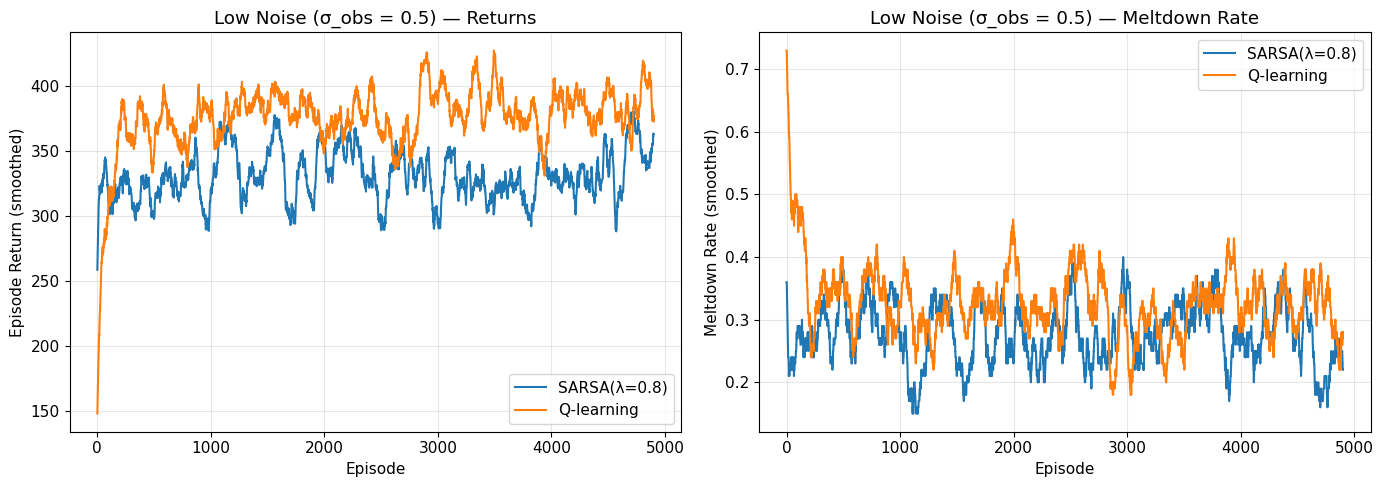

In [7]:
# Learning curves — low noise
plot_learning_curves({
    'SARSA(λ=0.8)': (ret_sarsa_low, melt_sarsa_low),
    'Q-learning': (ret_ql_low, melt_ql_low),
}, title='Low Noise (σ_obs = 0.5)', window=100)

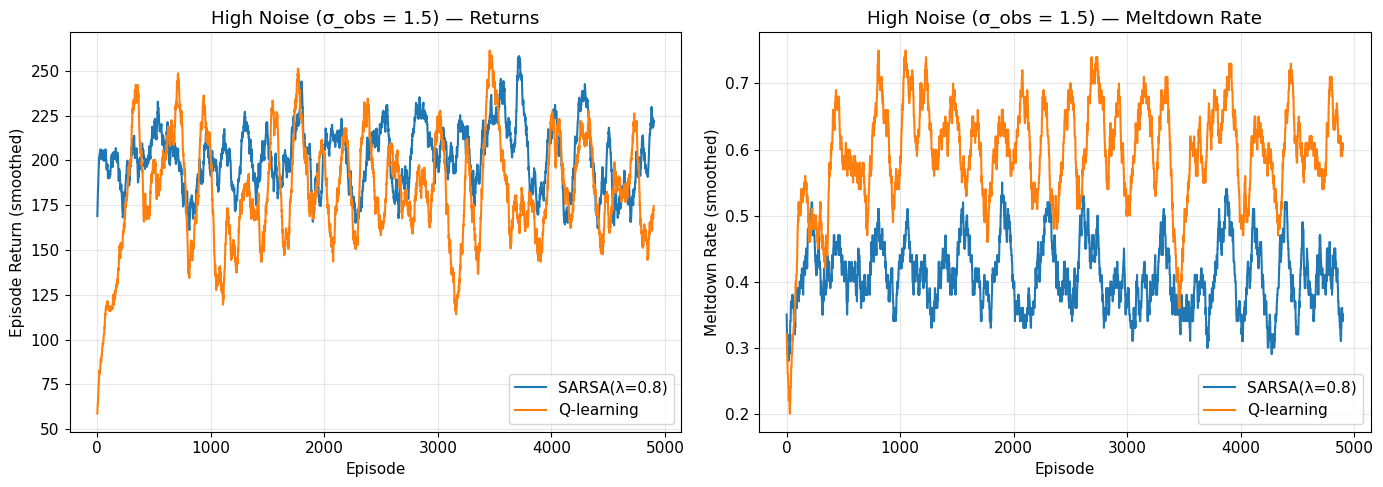

In [8]:
# Learning curves — high noise
plot_learning_curves({
    'SARSA(λ=0.8)': (ret_sarsa_high, melt_sarsa_high),
    'Q-learning': (ret_ql_high, melt_ql_high),
}, title='High Noise (σ_obs = 1.5)', window=100)

**Observations:**
- Under low noise, both algorithms learn to avoid meltdowns relatively quickly, with returns steadily increasing.
- Under high noise, learning is slower and noisier because the observation $z_t$ is a poor proxy for $\mu_t$, increasing state aliasing.
- Q-learning may initially achieve slightly higher returns (optimistic about the greedy policy) but may also suffer more meltdowns during exploration.
- SARSA tends to be more conservative — fewer meltdowns during training, potentially at the cost of slightly lower peak returns.

### 3(b) Q-function Heatmap

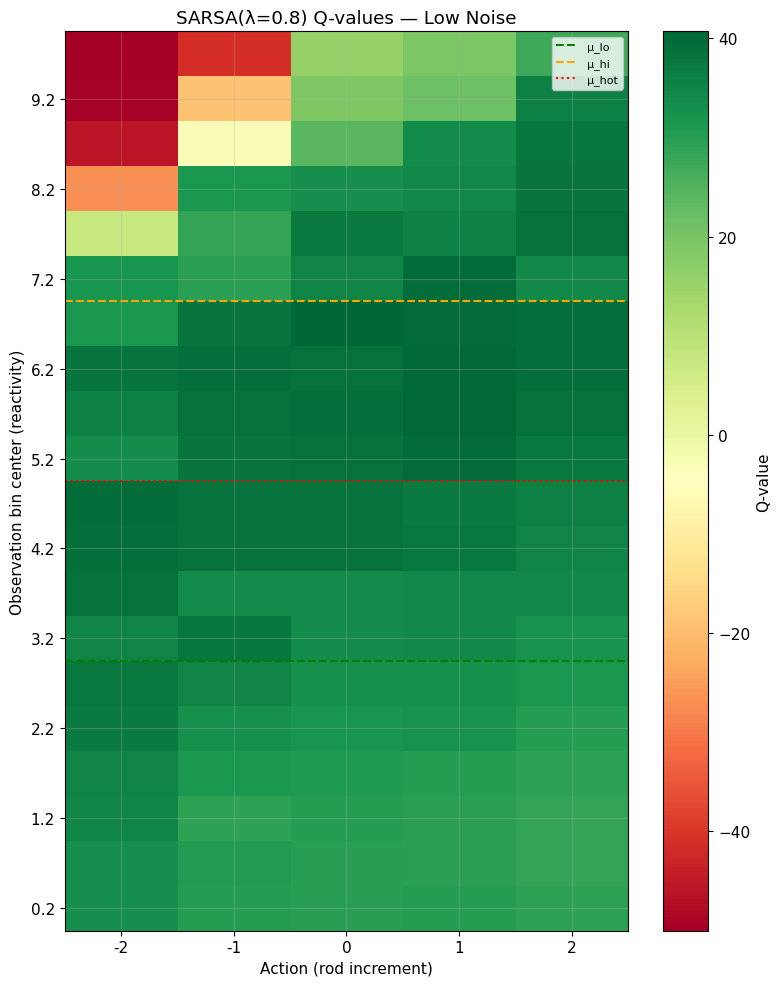

In [9]:
plot_q_heatmap(Q_sarsa_low, env_low, title='SARSA(λ=0.8) Q-values — Low Noise')

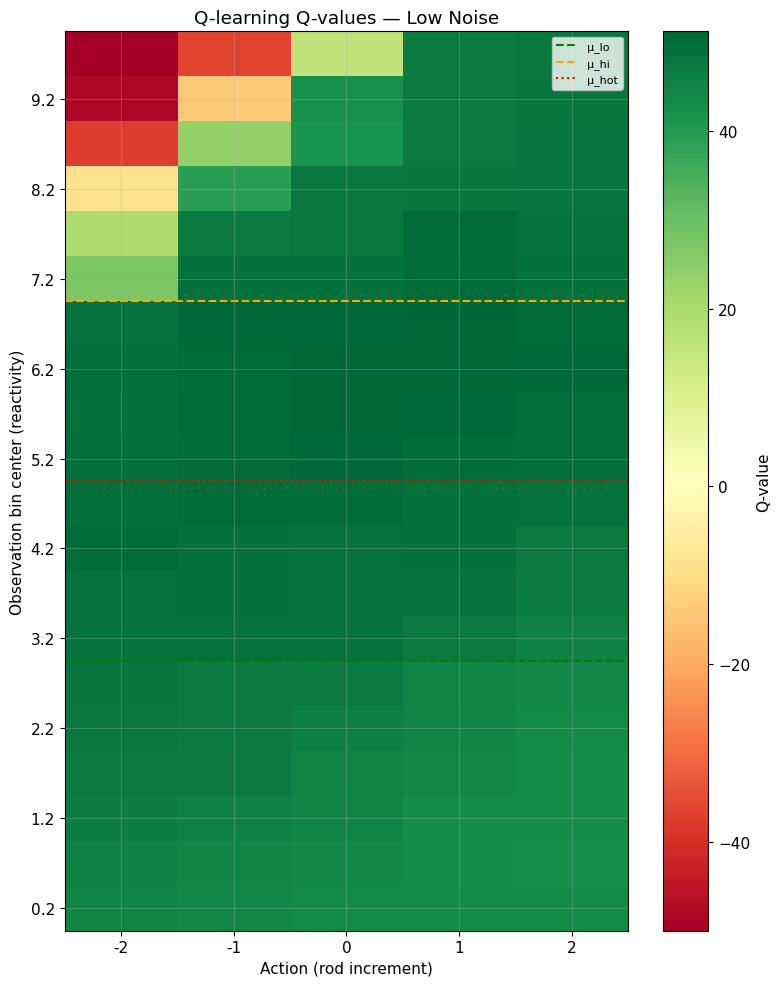

In [10]:
plot_q_heatmap(Q_ql_low, env_low, title='Q-learning Q-values — Low Noise')

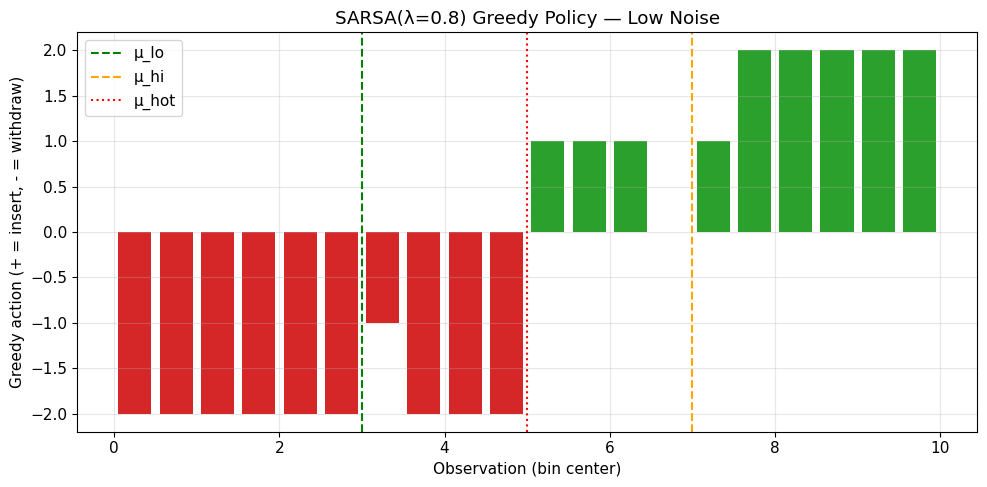

In [11]:
plot_greedy_policy(Q_sarsa_low, env_low, title='SARSA(λ=0.8) Greedy Policy — Low Noise')

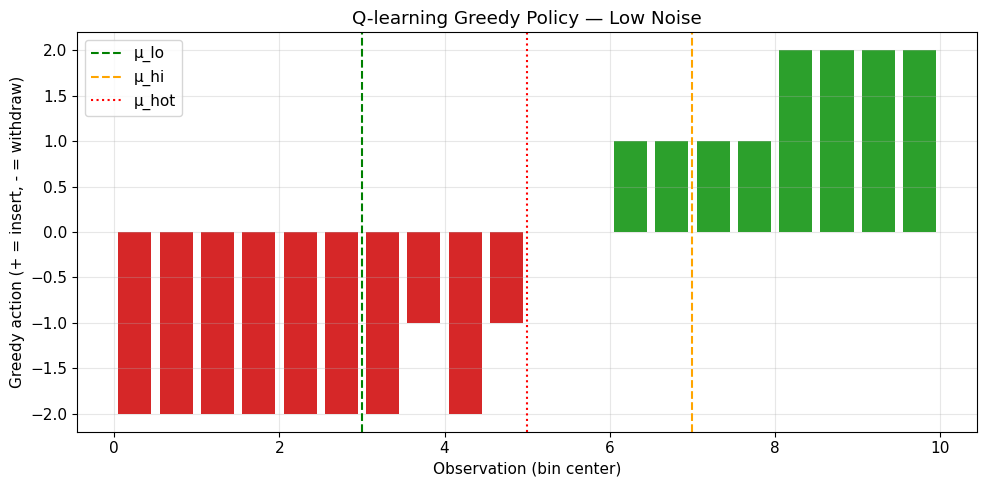

In [12]:
plot_greedy_policy(Q_ql_low, env_low, title='Q-learning Greedy Policy — Low Noise')

**Expected pattern in the Q heatmap:**
- In the **low observation bins** (cold reactor): withdrawing rods (negative actions) should have the highest Q-values — the agent needs to increase reactivity to enter the productive range.
- In the **productive range** ($\mu_{\text{lo}}$ to $\mu_{\text{hi}}$): small adjustments (action ≈ 0) should be optimal. The Q-values should be highest here.
- In the **high observation bins** (near $\mu_{\max}$): inserting rods (positive actions) should be strongly preferred — the agent must prevent meltdown. All Q-values should be low (reflecting the proximity to the catastrophic $-M$ penalty).
- The greedy policy should show a clear "withdraw when cold, hold when productive, insert when hot" pattern.

### 3(c) Algorithm Comparison: SARSA(λ=0) vs SARSA(λ=0.8)

In [13]:
# SARSA with lambda=0 (pure TD)
env_cmp = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=42)
print('Training SARSA(λ=0) — low noise...')
Q_s0, ret_s0, melt_s0 = sarsa_lambda(
    env_cmp, n_episodes=N_EPISODES, lam=0.0, seed=42)

# SARSA with lambda=0.8
env_cmp = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=42)
print('Training SARSA(λ=0.8) — low noise...')
Q_s8, ret_s8, melt_s8 = sarsa_lambda(
    env_cmp, n_episodes=N_EPISODES, lam=0.8, seed=42)

print('Training complete.')

Training SARSA(λ=0) — low noise...
Training SARSA(λ=0.8) — low noise...
Training complete.


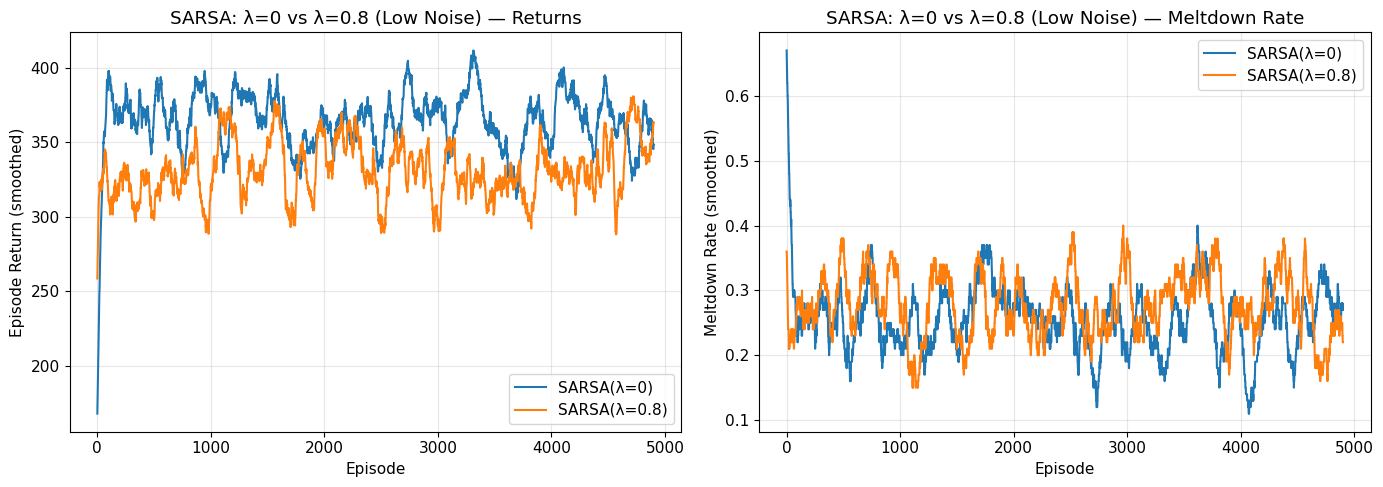

In [14]:
plot_learning_curves({
    'SARSA(λ=0)': (ret_s0, melt_s0),
    'SARSA(λ=0.8)': (ret_s8, melt_s8),
}, title='SARSA: λ=0 vs λ=0.8 (Low Noise)', window=100)

In [15]:
# Also compare SARSA vs Q-learning final performance
def evaluate_policy(Q, env, n_eval=200, seed=99):
    """Evaluate the greedy policy derived from Q."""
    env_eval = ReactorEnv(env.cfg, seed=seed)
    returns, melts = [], []
    for ep in range(n_eval):
        s, _ = env_eval.reset()
        total_r = 0.0
        done = False
        melted = False
        while not done:
            a = int(np.argmax(Q[s]))
            s, r, term, trunc, _ = env_eval.step(a)
            done = term or trunc
            melted = melted or term
            total_r += r
        returns.append(total_r)
        melts.append(melted)
    return np.mean(returns), np.std(returns), np.mean(melts)

print('=== Evaluation (greedy policy, 200 episodes, low noise) ===')
for name, Q_eval in [('SARSA(λ=0)', Q_s0), ('SARSA(λ=0.8)', Q_s8),
                      ('Q-learning', Q_ql_low)]:
    mean_r, std_r, melt_rate = evaluate_policy(Q_eval, env_low)
    print(f'  {name:20s}: return = {mean_r:7.1f} ± {std_r:5.1f}, '
          f'meltdown rate = {melt_rate:.1%}')

print()
print('=== Evaluation (greedy policy, 200 episodes, high noise) ===')
for name, Q_eval in [('SARSA(λ=0.8)', Q_sarsa_high),
                      ('Q-learning', Q_ql_high)]:
    mean_r, std_r, melt_rate = evaluate_policy(Q_eval, env_high)
    print(f'  {name:20s}: return = {mean_r:7.1f} ± {std_r:5.1f}, '
          f'meltdown rate = {melt_rate:.1%}')

=== Evaluation (greedy policy, 200 episodes, low noise) ===
  SARSA(λ=0)          : return =   476.9 ±  20.5, meltdown rate = 0.0%
  SARSA(λ=0.8)        : return =   407.3 ±  17.1, meltdown rate = 0.0%
  Q-learning          : return =   517.0 ±  15.5, meltdown rate = 0.0%

=== Evaluation (greedy policy, 200 episodes, high noise) ===
  SARSA(λ=0.8)        : return =   295.8 ±  26.7, meltdown rate = 0.0%
  Q-learning          : return =   375.1 ±  37.7, meltdown rate = 4.0%


**Discussion of comparison:**

- **SARSA(λ=0) vs SARSA(λ=0.8):** We expect $\lambda=0.8$ to converge faster because the eligibility traces propagate the meltdown penalty backward through multiple states in a single episode. With $\lambda=0$, learning is one-step-at-a-time — it takes many episodes for the penalty signal to propagate from the critical region all the way back to the warm-up states.

- **SARSA vs Q-learning:** Q-learning typically achieves higher asymptotic return because it learns the optimal (greedy) value function. However, SARSA is safer during training — its on-policy nature means it accounts for the $\varepsilon$-greedy exploration, learning to stay further from the critical region. This results in fewer meltdowns during the training process.

- **Convergence speed:** SARSA($\lambda=0.8$) is expected to be the fastest to converge because it combines the safety benefits of on-policy learning with efficient multi-step credit assignment via eligibility traces.

### Trajectory Visualization: Learned Policy in Action

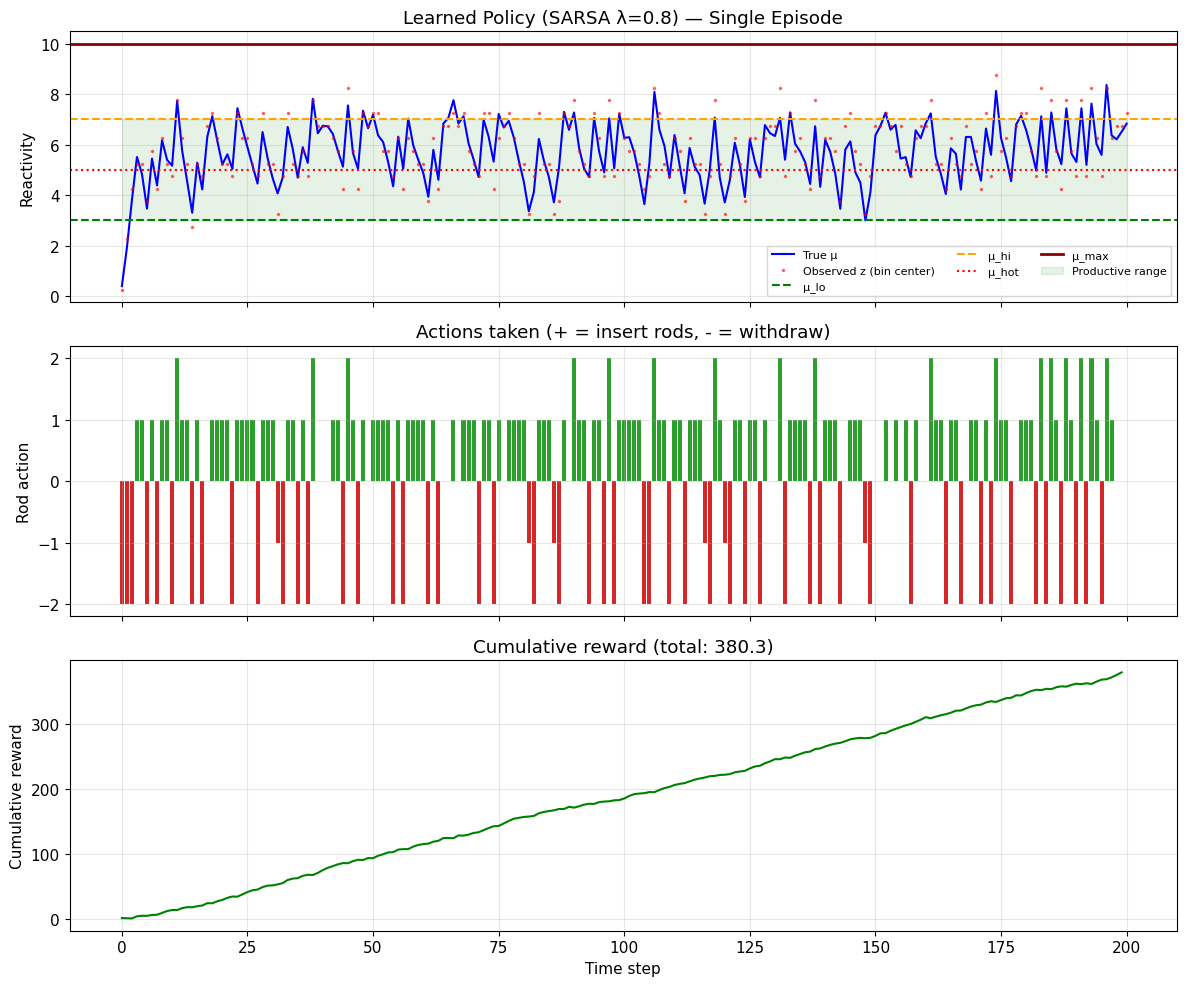

Episode length: 200, Meltdown: False, Total reward: 380.3


In [16]:
# Show a single episode with the learned SARSA policy
greedy_policy_fn = lambda s: int(np.argmax(Q_sarsa_low[s]))

env_vis = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=77)
states_vis, acts_vis, rews_vis, mus_vis = run_episode(env_vis, greedy_policy_fn)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

t_range = np.arange(len(mus_vis))
axes[0].plot(t_range, mus_vis, 'b-', lw=1.5, label='True μ')
obs_vals = [env_vis._bin_center(s) for s in states_vis]
axes[0].plot(t_range, obs_vals, 'r.', ms=3, alpha=0.5, label='Observed z (bin center)')
axes[0].axhline(env_vis.cfg.mu_lo, color='green', ls='--', label='μ_lo')
axes[0].axhline(env_vis.cfg.mu_hi, color='orange', ls='--', label='μ_hi')
axes[0].axhline(env_vis.cfg.mu_hot, color='red', ls=':', label='μ_hot')
axes[0].axhline(env_vis.cfg.mu_max, color='darkred', ls='-', lw=2, label='μ_max')
axes[0].fill_between(t_range, env_vis.cfg.mu_lo, env_vis.cfg.mu_hi,
                     alpha=0.1, color='green', label='Productive range')
axes[0].set_ylabel('Reactivity')
axes[0].set_title('Learned Policy (SARSA λ=0.8) — Single Episode')
axes[0].legend(fontsize=8, ncol=3)

axes[1].bar(range(len(acts_vis)), acts_vis, color=['#d62728' if a < 0 else '#2ca02c' if a > 0 else '#7f7f7f' for a in acts_vis])
axes[1].set_ylabel('Rod action')
axes[1].set_title('Actions taken (+ = insert rods, - = withdraw)')

axes[2].plot(np.cumsum(rews_vis), 'g-', lw=1.5)
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Cumulative reward')
axes[2].set_title(f'Cumulative reward (total: {sum(rews_vis):.1f})')

plt.tight_layout()
plt.show()

melted = mus_vis[-1] >= env_vis.cfg.mu_max
print(f'Episode length: {len(acts_vis)}, Meltdown: {melted}, '
      f'Total reward: {sum(rews_vis):.1f}')

---
## Question 4: CHALLENGE

### 4(a) Linear Function Approximation with RBF Features

We implement **semi-gradient SARSA($\lambda$)** with linear function approximation [Sutton & Barto, 2018, Ch. 9–12] using Radial Basis Function (RBF) features [Busoniu et al., 2010]. The semi-gradient update only differentiates through the prediction, not the target — a necessary design choice for bootstrapping methods to remain stable [Sutton & Barto, 2018, Ch. 11].

In [17]:
class RBFFeatures:
    """
    Radial Basis Function feature constructor.
    Centers placed at each bin center; one set of RBFs per action.
    """

    def __init__(self, env, bandwidth=1.0):
        self.centers = np.array([env._bin_center(s) for s in range(env.n_states)])
        self.bandwidth = bandwidth
        self.n_centers = len(self.centers)
        self.n_actions = env.n_actions
        self.dim = self.n_centers * self.n_actions  # total feature dimension

    def __call__(self, s: int, a: int) -> np.ndarray:
        """Return phi(s, a) — feature vector."""
        z = self.centers[s]  # use bin center as the continuous proxy
        rbf = np.exp(-0.5 * ((z - self.centers) / self.bandwidth) ** 2)
        phi = np.zeros(self.dim)
        start = a * self.n_centers
        phi[start:start + self.n_centers] = rbf
        return phi


def semi_gradient_sarsa(env, n_episodes=5000, alpha=0.01, gamma=0.95,
                        lam=0.8, epsilon=0.15, bandwidth=1.0, seed=42):
    """
    Semi-gradient SARSA(lambda) with linear function approximation.
    Q_hat(s, a; w) = w^T phi(s, a)
    """
    rng_local = np.random.default_rng(seed)
    nA = env.n_actions
    features = RBFFeatures(env, bandwidth=bandwidth)
    w = np.zeros(features.dim)
    episode_returns = []
    meltdowns = []

    def q_hat(s, a):
        return w @ features(s, a)

    def eps_greedy(s):
        if rng_local.random() < epsilon:
            return rng_local.integers(nA)
        q_vals = [q_hat(s, a) for a in range(nA)]
        return int(np.argmax(q_vals))

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        z = np.zeros(features.dim)  # eligibility trace vector
        total_r = 0.0
        melted = False

        done = False
        while not done:
            s_next, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            melted = melted or terminated

            a_next = eps_greedy(s_next) if not done else 0

            q_s_a = q_hat(s, a)
            q_next = q_hat(s_next, a_next) if not terminated else 0.0
            td_error = r + gamma * q_next - q_s_a

            phi_sa = features(s, a)
            z = gamma * lam * z + phi_sa  # accumulating traces
            w += alpha * td_error * z

            total_r += r
            s, a = s_next, a_next

        episode_returns.append(total_r)
        meltdowns.append(melted)

    return w, features, episode_returns, meltdowns


# Train the linear FA agent
env_fa = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=42)
print('Training Semi-gradient SARSA(λ=0.8) with RBF features...')
w_fa, feats_fa, ret_fa, melt_fa = semi_gradient_sarsa(
    env_fa, n_episodes=N_EPISODES, alpha=0.005, bandwidth=0.8, seed=42)
print('Training complete.')

Training Semi-gradient SARSA(λ=0.8) with RBF features...
Training complete.


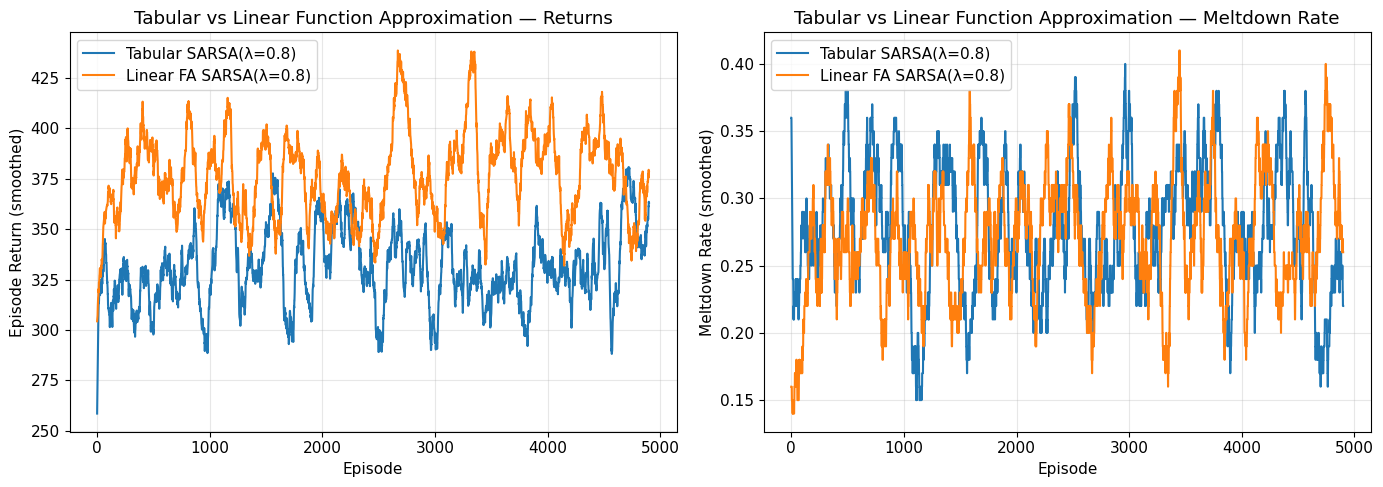

In [18]:
# Compare tabular vs linear FA
plot_learning_curves({
    'Tabular SARSA(λ=0.8)': (ret_sarsa_low, melt_sarsa_low),
    'Linear FA SARSA(λ=0.8)': (ret_fa, melt_fa),
}, title='Tabular vs Linear Function Approximation', window=100)

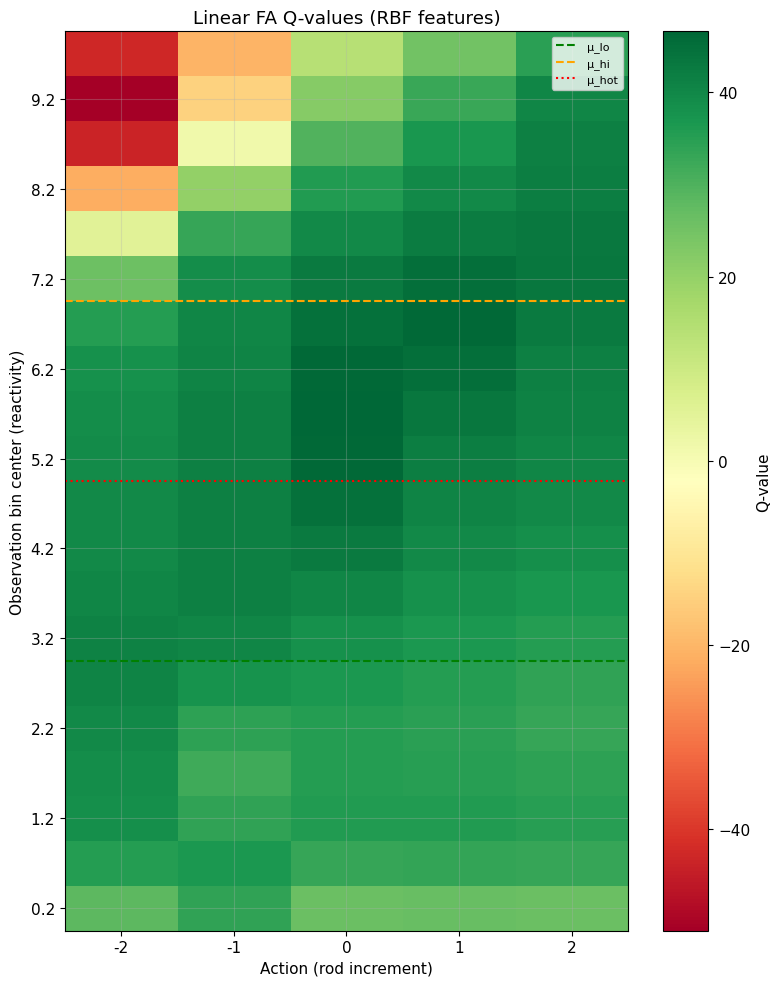

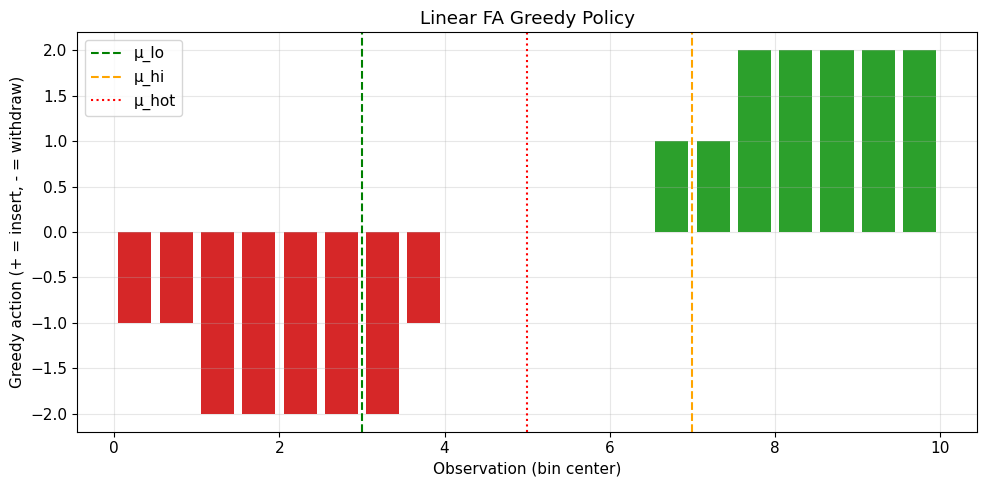

In [19]:
# Reconstruct the Q-table from the linear FA for comparison
Q_fa = np.zeros((env_fa.n_states, env_fa.n_actions))
for s in range(env_fa.n_states):
    for a in range(env_fa.n_actions):
        Q_fa[s, a] = w_fa @ feats_fa(s, a)

plot_q_heatmap(Q_fa, env_fa, title='Linear FA Q-values (RBF features)')
plot_greedy_policy(Q_fa, env_fa, title='Linear FA Greedy Policy')

**Discussion — Linear FA vs Tabular:**

The RBF-based linear function approximator generalizes across neighboring bins: updating the value for one observation affects nearby observations through the overlapping RBF features. This should lead to **faster initial learning** (fewer episodes to fill in the Q-table) but potentially lower **asymptotic precision** than the tabular method, since the linear representation cannot capture arbitrary state-action value landscapes.

Semi-gradient TD converges here because the features are fixed (not learned) and the problem is on-policy.

### 4(b) Non-stationarity Investigation: Does Q-learning Track the Drift?

In [ ]:
# Compare constant alpha vs decaying alpha
env_ns = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=42)
print('Q-learning with constant α=0.1 ...')
Q_const, ret_const, melt_const = q_learning(
    env_ns, n_episodes=N_EPISODES, alpha=0.1, seed=42)

# Decaying learning rate version
def q_learning_decay(env, n_episodes=5000, alpha0=0.3, gamma=0.95,
                     epsilon=0.15, seed=42):
    """Q-learning with decaying per-state-action learning rate."""
    rng_local = np.random.default_rng(seed)
    nS, nA = env.n_states, env.n_actions
    Q = np.zeros((nS, nA))
    visit_count = np.zeros((nS, nA))
    episode_returns = []
    meltdowns = []

    def eps_greedy(state):
        if rng_local.random() < epsilon:
            return rng_local.integers(nA)
        return int(np.argmax(Q[state]))

    for ep in range(n_episodes):
        s, _ = env.reset()
        total_r = 0.0
        melted = False
        done = False
        while not done:
            a = eps_greedy(s)
            s_next, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            melted = melted or terminated

            visit_count[s, a] += 1
            alpha_t = alpha0 / (1 + 0.001 * visit_count[s, a])
            td_target = r + gamma * np.max(Q[s_next]) * (1 - float(terminated))
            Q[s, a] += alpha_t * (td_target - Q[s, a])

            total_r += r
            s = s_next

        episode_returns.append(total_r)
        meltdowns.append(melted)

    return Q, episode_returns, meltdowns


env_ns = ReactorEnv(ReactorConfig(sigma_obs=0.5), seed=42)
print('Q-learning with decaying α ...')
Q_decay, ret_decay, melt_decay = q_learning_decay(
    env_ns, n_episodes=N_EPISODES, seed=42)

print('Training complete.')

In [ ]:
plot_learning_curves({
    'Q-learning (constant α=0.1)': (ret_const, melt_const),
    'Q-learning (decaying α)': (ret_decay, melt_decay),
}, title='Non-stationarity: Constant vs Decaying Learning Rate', window=100)

print('=== Final evaluation ===')
for name, Q_eval in [('Constant α', Q_const), ('Decaying α', Q_decay)]:
    mean_r, std_r, melt_rate = evaluate_policy(Q_eval, env_ns)
    print(f'  {name:20s}: return = {mean_r:7.1f} ± {std_r:5.1f}, '
          f'meltdown rate = {melt_rate:.1%}')

**Discussion — Non-stationarity:**

The drift $d(\mu)$ makes the transition dynamics state-dependent but **not time-varying** — the drift is a deterministic function of $\mu_t$, so it is already captured in the (stationary) MDP transition structure. The Q-learning agent **implicitly** learns to account for the drift because it observes its effects in the transitions: states near $\mu_{\text{hot}}$ naturally transition toward higher reactivity, and the learned Q-values reflect this tendency.

A constant learning rate actually has an advantage here: it keeps the agent responsive to the inherent stochasticity. A decaying learning rate converges to a fixed Q-function, which may be slightly sharper but less adaptive. In practice, both should perform similarly because the non-stationarity is **within-episode** (the drift), not **across-episode** (the dynamics don't change between episodes).

### 4(c) Discussion: Continuous Action Space

If $a \in [-k, k] \subset \mathbb{R}$ (continuous rod insertion rate), the algorithms above face these obstacles:

1. **Q-learning/SARSA require $\max_a Q(s, a)$**, which requires searching over a continuous set. With a tabular or linear Q-function, this maximization has no closed form.

2. **The action space cannot be enumerated**, so $\varepsilon$-greedy exploration (pick a random action) now requires sampling from a continuous distribution rather than a finite set.

3. **Discretizing** the action space is possible but introduces quantization error and scales exponentially with action dimensionality.

**Actor-critic methods** address these issues by maintaining:
- A **critic** $Q_\phi(s, a)$ (or $V_\phi(s)$) parameterized by a neural network that can evaluate any continuous $(s, a)$ pair.
- An **actor** $\pi_\theta(a \mid s)$ — a parameterized policy (e.g., Gaussian $\mathcal{N}(\mu_\theta(s), \sigma_\theta(s))$) that directly outputs continuous actions.

The actor is updated by policy gradient: $\nabla_\theta J \approx \mathbb{E}[\nabla_\theta \log \pi_\theta(a|s) \cdot A^\pi(s,a)]$, where the advantage $A^\pi$ is estimated by the critic. This avoids the $\max_a$ operation entirely.

Algorithms like **PPO** (Proximal Policy Optimization) [Schulman et al., 2017] or **SAC** (Soft Actor-Critic) [Haarnoja et al., 2018] are the standard choices for continuous control. The policy gradient theorem [Sutton et al., 2000] provides the theoretical basis for these methods. Interestingly, PPO is exactly what we are using for the robot reaching task in our Isaac Sim 06c training script — the same underlying algorithm framework applies whether the agent is controlling nuclear rods or robot joints.

---
## Summary

| Aspect | Finding |
|---|---|
| **MDP formulation** | Discretized POMDP with $n=20$ bins, $|A|=5$, $\gamma=0.95$ |
| **Best algorithm** | SARSA($\lambda=0.8$): fast convergence + safe exploration |
| **Noise effect** | Higher $\sigma_{\text{obs}}$ slows learning and increases meltdowns |
| **$\lambda$ effect** | Higher $\lambda$ propagates meltdown penalty faster → quicker learning |
| **On vs off-policy** | SARSA (on-policy) is safer; Q-learning (off-policy) slightly higher return |
| **Linear FA** | RBF features enable generalization; competitive with tabular |
| **Non-stationarity** | Drift is implicit in stationary MDP; Q-learning handles it automatically |

---
## References

1. **Sutton, R. S. & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. [http://incompleteideas.net/book/the-book-2nd.html](http://incompleteideas.net/book/the-book-2nd.html)
   - Ch. 6: Temporal-Difference Learning (SARSA, Q-learning)
   - Ch. 9: On-policy Prediction with Approximation (linear FA, RBF features)
   - Ch. 12: Eligibility Traces (SARSA($\lambda$), replacing traces)
   - Ch. 17.3: Applications to POMDPs

2. **Watkins, C. J. C. H. & Dayan, P.** (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292. [https://doi.org/10.1007/BF00992698](https://doi.org/10.1007/BF00992698)

3. **Rummery, G. A. & Niranjan, M.** (1994). On-line Q-learning using connectionist systems. *Technical Report CUED/F-INFENG/TR 166*, Cambridge University.

4. **Singh, S. P. & Sutton, R. S.** (1996). Reinforcement learning with replacing eligibility traces. *Machine Learning*, 22(1–3), 123–158. [https://doi.org/10.1007/BF00114726](https://doi.org/10.1007/BF00114726)

5. **Kaelbling, L. P., Littman, M. L., & Cassandra, A. R.** (1998). Planning and acting in partially observable stochastic domains. *Artificial Intelligence*, 101(1–2), 99–134. [https://doi.org/10.1016/S0004-3702(98)00023-X](https://doi.org/10.1016/S0004-3702(98)00023-X)

6. **Busoniu, L., Babuska, R., De Schutter, B., & Ernst, D.** (2010). *Reinforcement Learning and Dynamic Programming Using Function Approximators*. CRC Press.

7. **Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O.** (2017). Proximal Policy Optimization Algorithms. *arXiv preprint arXiv:1707.06347*. [https://arxiv.org/abs/1707.06347](https://arxiv.org/abs/1707.06347)

8. **Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S.** (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. *Proceedings of ICML 2018*. [https://arxiv.org/abs/1801.01290](https://arxiv.org/abs/1801.01290)

9. **Sutton, R. S., McAllester, D., Singh, S., & Mansour, Y.** (2000). Policy Gradient Methods for Reinforcement Learning with Function Approximation. *Advances in Neural Information Processing Systems 12 (NeurIPS 1999)*.